# Model Comparison Analysis

This notebook provides comprehensive visual and statistical comparisons across all trained models:
- **Baseline CNN**
- **MobileNetV2** (Transfer Learning)
- **ResNet50** (Transfer Learning)
- **VGG16** (Transfer Learning)

## Analysis Sections:
1. **Prediction Confidence Distributions** - How confident each model is
2. **Model Agreement Analysis** - Where models agree/disagree
3. **Top Agreed/Disagreed Cases** - Most unanimous vs most controversial predictions
4. **Pairwise Agreement Heatmap** - Model similarity matrix
5. **Confidence Comparison** - Statistical distribution analysis
6. **Sample Predictions Gallery** - Visual side-by-side comparisons
7. **Comprehensive Summary** - Overall statistics table

## Setup & Load Predictions

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load all prediction CSVs
output_dir = Path('outputs')
models = {
    'Baseline CNN': 'predictions_baseline.csv',
    'MobileNetV2': 'predictions_mobilenetv2.csv',
    'ResNet50': 'predictions_resnet50.csv',
    'VGG16': 'predictions_vgg16.csv'
}

predictions = {}
for name, filename in models.items():
    filepath = output_dir / filename
    if filepath.exists():
        predictions[name] = pd.read_csv(filepath)
        print(f"Loaded {name}: {len(predictions[name])} predictions")
    else:
        print(f"Missing {name}: {filepath}")

print(f"\n{len(predictions)} models loaded successfully")

Loaded Baseline CNN: 500 predictions
Loaded MobileNetV2: 500 predictions
Loaded ResNet50: 500 predictions
Loaded VGG16: 500 predictions

4 models loaded successfully


## 1. Prediction Confidence Distributions

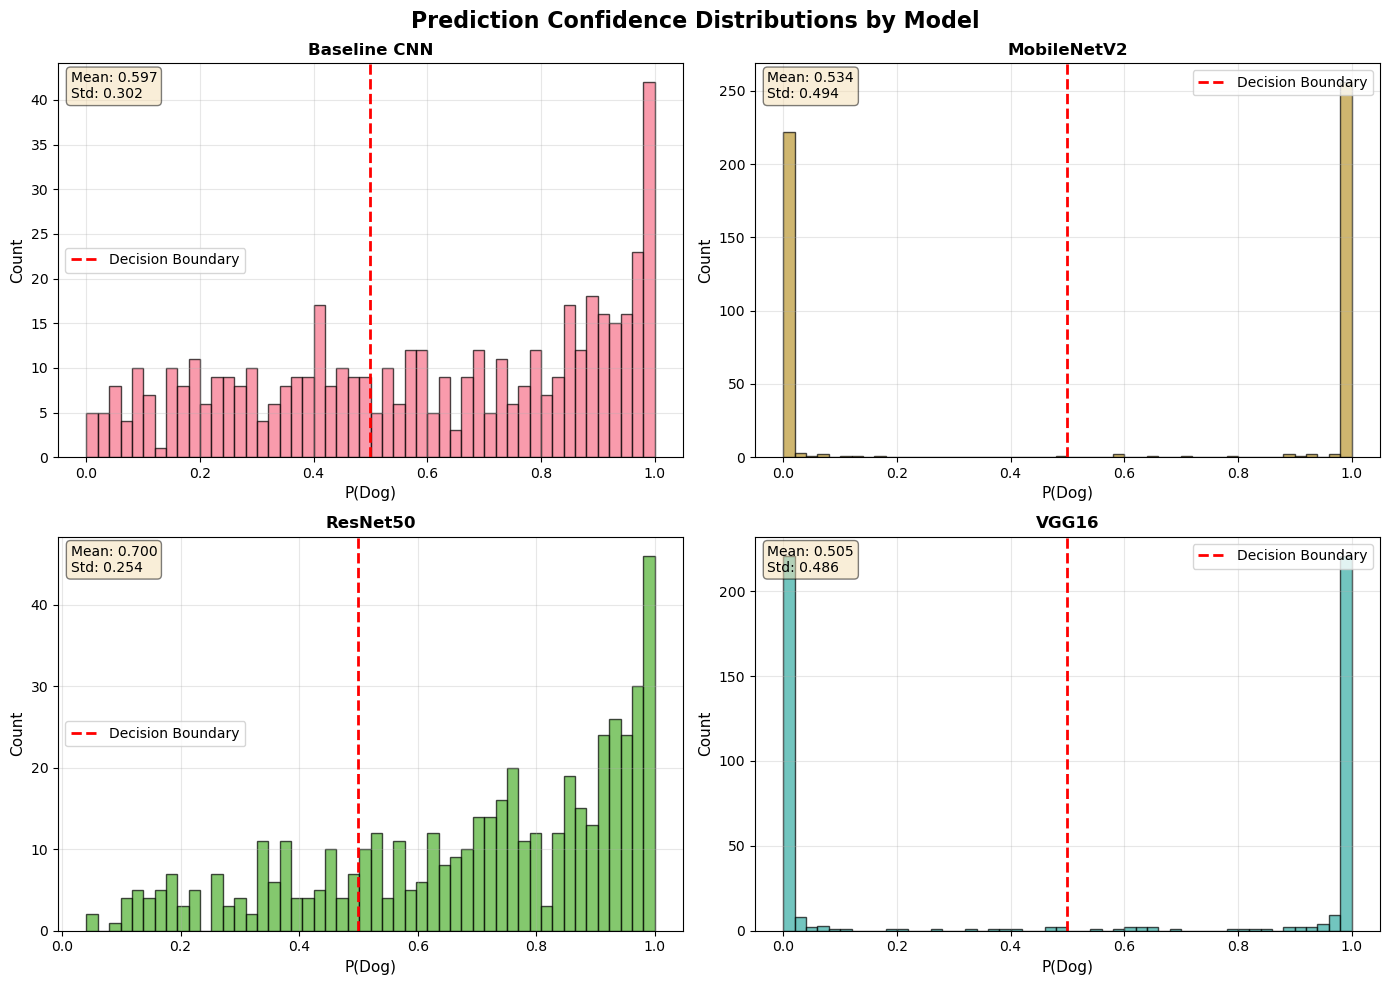

Saved: comparison_confidence_distributions.png


In [35]:
# PREDICTION CONFIDENCE DISTRIBUTIONS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Prediction Confidence Distributions by Model', fontsize=16, fontweight='bold')

for idx, (name, df) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]
    
    # Plot histogram of probabilities
    ax.hist(df['prob_dog'], bins=50, alpha=0.7, color=f'C{idx}', edgecolor='black')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
    ax.set_xlabel('P(Dog)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Add statistics
    mean_conf = df['prob_dog'].mean()
    std_conf = df['prob_dog'].std()
    ax.text(0.02, 0.98, f'Mean: {mean_conf:.3f}\nStd: {std_conf:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(output_dir / 'comparison_confidence_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_confidence_distributions.png")

## 2. Model Agreement Analysis

In [36]:
# MODEL AGREEMENT ANALYSIS
# Create a merged dataframe with all predictions
merged = predictions[list(predictions.keys())[0]][['filename']].copy()

for name, df in predictions.items():
    merged[f'{name}_pred'] = df['pred_label']
    merged[f'{name}_prob'] = df['prob_dog']

# Calculate agreement across models
def calculate_agreement(row):
    pred_cols = [col for col in row.index if col.endswith('_pred')]
    preds = row[pred_cols].values
    return np.sum(preds == preds[0]) == len(preds)

merged['all_agree'] = merged.apply(calculate_agreement, axis=1)
agreement_rate = merged['all_agree'].mean() * 100

print(f"MODEL AGREEMENT ANALYSIS")
print(f"=" * 50)
print(f"All models agree: {merged['all_agree'].sum()}/{len(merged)} images ({agreement_rate:.1f}%)")
print(f"Models disagree: {(~merged['all_agree']).sum()} images ({100-agreement_rate:.1f}%)")
print()

# Show disagreement cases
disagreements = merged[~merged['all_agree']]
if len(disagreements) > 0:
    print(f"Disagreement cases (first 10):")
    print("-" * 50)
    pred_cols = [col for col in merged.columns if col.endswith('_pred')]
    prob_cols = [col for col in merged.columns if col.endswith('_prob')]
    display_cols = ['filename'] + pred_cols + prob_cols
    print(disagreements[display_cols].head(10).to_string(index=False))
else:
    print("All models agree on all predictions!")

MODEL AGREEMENT ANALYSIS
All models agree: 294/500 images (58.8%)
Models disagree: 206 images (41.2%)

Disagreement cases (first 10):
--------------------------------------------------
filename Baseline CNN_pred MobileNetV2_pred ResNet50_pred VGG16_pred  Baseline CNN_prob  MobileNetV2_prob  ResNet50_prob   VGG16_prob
   1.jpg               cat              cat           dog        cat           0.279450          0.000039       0.530948 3.121569e-04
 101.jpg               cat              cat           dog        cat           0.012332          0.000021       0.615976 9.218102e-10
 110.jpg               cat              cat           dog        cat           0.469863          0.000088       0.740536 4.373586e-09
 111.jpg               cat              cat           dog        cat           0.224519          0.000004       0.532482 3.521130e-14
  12.jpg               dog              cat           dog        cat           0.725983          0.000023       0.614888 2.950491e-05
 120.jpg   

## 3. Top 10 Most Agreed vs Most Disagreed

In [37]:
# TOP 10 MOST AGREED vs TOP 10 MOST DISAGREED
print("\n" + "="*80)
print("TOP 10 MOST AGREED PREDICTIONS (All Models Confident & Agreement)")
print("="*80)

# Calculate confidence variance (lower = more agreement in confidence)
prob_cols = [col for col in merged.columns if col.endswith('_prob')]
merged['prob_variance'] = merged[prob_cols].var(axis=1)
merged['mean_prob'] = merged[prob_cols].mean(axis=1)

# Most agreed: all predict same AND similar confidence levels
most_agreed = merged[merged['all_agree']].nsmallest(10, 'prob_variance')

print("\nThese images had unanimous predictions with very similar confidence levels:\n")
for i, (_, row) in enumerate(most_agreed.iterrows(), 1):
    print(f"{i}. {row['filename']:<15} | Mean P(Dog): {row['mean_prob']:.3f} | Variance: {row['prob_variance']:.6f}")
    for name in predictions.keys():
        pred_val = row[f'{name}_pred']
        # Handle both string ('dog'/'cat') and numeric (1/0) predictions
        pred = 'Dog' if (pred_val == 'dog' or pred_val == 1) else 'Cat'
        prob = row[f'{name}_prob']
        print(f"   {name:<15}: {pred:>3} ({prob:.4f})")
    print()

print("\n" + "="*80)
print("TOP 10 MOST DISAGREED PREDICTIONS (Highest Variance in Confidence)")
print("="*80)

# Most disagreed: highest variance in probabilities OR mixed predictions
most_disagreed = merged.nlargest(10, 'prob_variance')

print("\nThese images had the most divergent predictions across models:\n")
for i, (_, row) in enumerate(most_disagreed.iterrows(), 1):
    agree_status = "AGREE" if row['all_agree'] else "DISAGREE"
    print(f"{i}. {row['filename']:<15} | {agree_status} | Mean P(Dog): {row['mean_prob']:.3f} | Variance: {row['prob_variance']:.6f}")
    for name in predictions.keys():
        pred_val = row[f'{name}_pred']
        # Handle both string ('dog'/'cat') and numeric (1/0) predictions
        pred = 'Dog' if (pred_val == 'dog' or pred_val == 1) else 'Cat'
        prob = row[f'{name}_prob']
        print(f"   {name:<15}: {pred:>3} ({prob:.4f})")
    print()

print("="*80)


TOP 10 MOST AGREED PREDICTIONS (All Models Confident & Agreement)

These images had unanimous predictions with very similar confidence levels:

1. 333.jpg         | Mean P(Dog): 1.000 | Variance: 0.000000
   Baseline CNN   : Dog (0.9988)
   MobileNetV2    : Dog (1.0000)
   ResNet50       : Dog (0.9997)
   VGG16          : Dog (1.0000)

2. 459.jpg         | Mean P(Dog): 0.999 | Variance: 0.000001
   Baseline CNN   : Dog (0.9990)
   MobileNetV2    : Dog (1.0000)
   ResNet50       : Dog (0.9977)
   VGG16          : Dog (1.0000)

3. 350.jpg         | Mean P(Dog): 0.999 | Variance: 0.000005
   Baseline CNN   : Dog (0.9994)
   MobileNetV2    : Dog (1.0000)
   ResNet50       : Dog (0.9955)
   VGG16          : Dog (1.0000)

4. 218.jpg         | Mean P(Dog): 0.999 | Variance: 0.000006
   Baseline CNN   : Dog (1.0000)
   MobileNetV2    : Dog (1.0000)
   ResNet50       : Dog (0.9952)
   VGG16          : Dog (1.0000)

5. 7.jpg           | Mean P(Dog): 0.997 | Variance: 0.000020
   Baseline CNN   

DATASET DISTRIBUTION:
Total images: 500
  - Cats (mean_prob < 0.5): 236
  - Dogs (mean_prob > 0.5): 264

All models agree: 294 images
  - Agreed on Cat: 83
  - Agreed on Dog: 211

Selected for visualization:
  Most Agreed Cats: 5
  Most Agreed Dogs: 5
  Most Disagreed Cats: 5
  Most Disagreed Dogs: 5


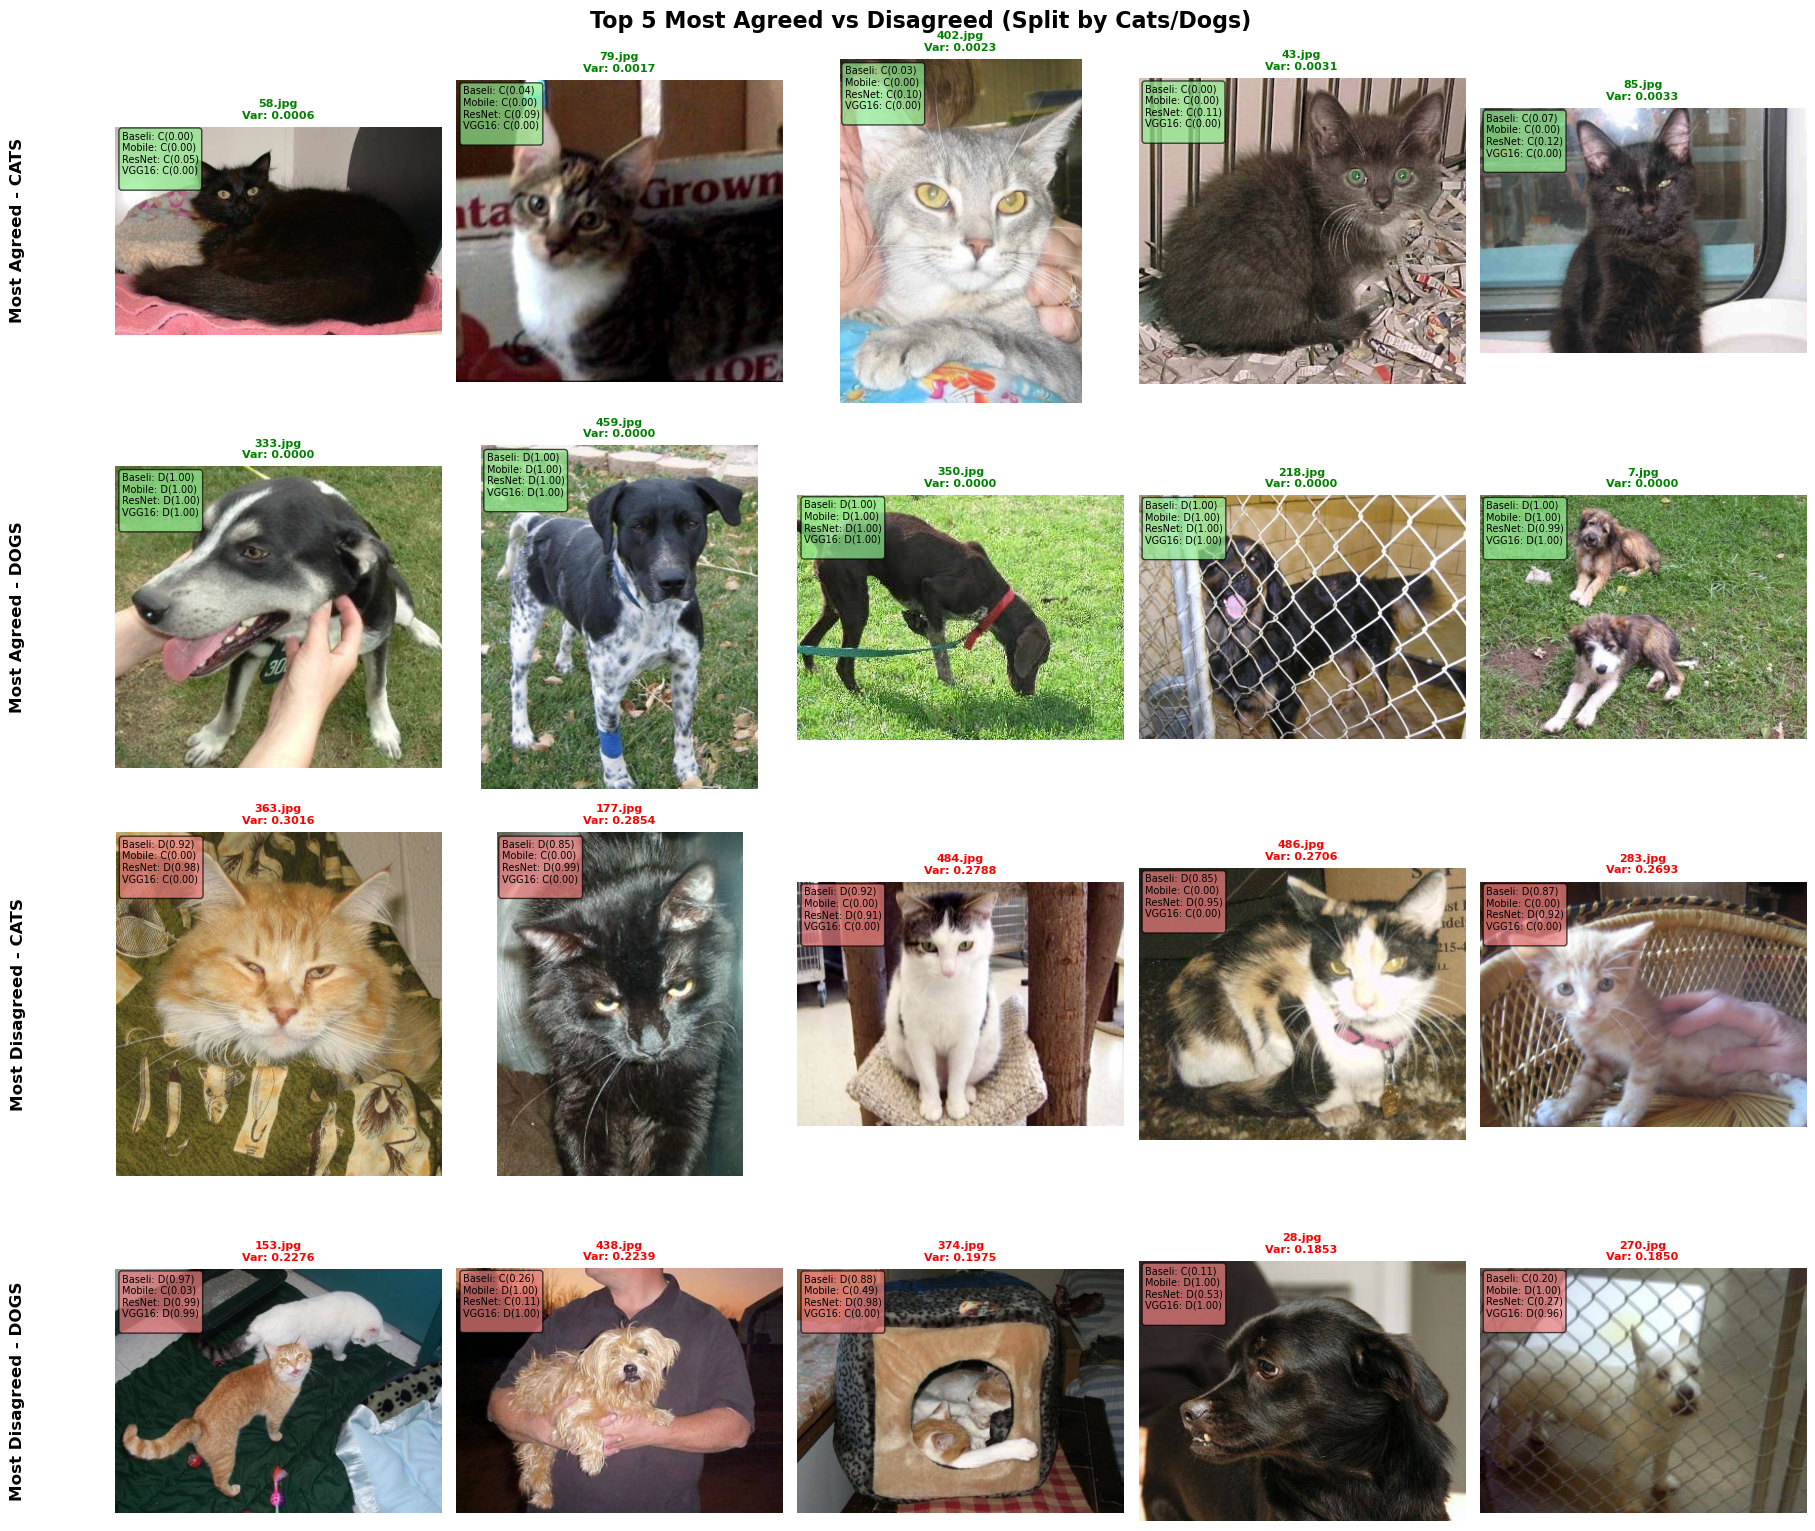


Saved: comparison_top_agreed_disagreed_split.png


In [38]:
# VISUALIZE TOP 5 AGREED vs TOP 5 DISAGREED - SPLIT BY CATS AND DOGS
# Determine true class based on mean probability
def get_true_class(row):
    """Determine the actual class based on mean probability across all models"""
    return 1 if row['mean_prob'] > 0.5 else 0

merged['true_class'] = merged.apply(get_true_class, axis=1)

# Get ALL agreed images split by class
all_agreed_cats = merged[(merged['all_agree']) & (merged['true_class'] == 0)].sort_values('prob_variance')
all_agreed_dogs = merged[(merged['all_agree']) & (merged['true_class'] == 1)].sort_values('prob_variance')

# Get ALL images (agreed or not) split by class, sorted by variance
all_cats = merged[merged['true_class'] == 0].sort_values('prob_variance', ascending=False)
all_dogs = merged[merged['true_class'] == 1].sort_values('prob_variance', ascending=False)

# Strategy: Take top 5 from agreed if available, otherwise take from all images
most_agreed_cats = all_agreed_cats.head(5) if len(all_agreed_cats) >= 5 else all_cats.nsmallest(5, 'prob_variance')
most_agreed_dogs = all_agreed_dogs.head(5) if len(all_agreed_dogs) >= 5 else all_dogs.nsmallest(5, 'prob_variance')
most_disagreed_cats = all_cats.head(5)
most_disagreed_dogs = all_dogs.head(5)

# Show detailed counts
print(f"=" * 60)
print(f"DATASET DISTRIBUTION:")
print(f"=" * 60)
print(f"Total images: {len(merged)}")
print(f"  - Cats (mean_prob < 0.5): {(merged['true_class'] == 0).sum()}")
print(f"  - Dogs (mean_prob > 0.5): {(merged['true_class'] == 1).sum()}")
print(f"\nAll models agree: {merged['all_agree'].sum()} images")
print(f"  - Agreed on Cat: {len(all_agreed_cats)}")
print(f"  - Agreed on Dog: {len(all_agreed_dogs)}")
print(f"\nSelected for visualization:")
print(f"  Most Agreed Cats: {len(most_agreed_cats)}")
print(f"  Most Agreed Dogs: {len(most_agreed_dogs)}")
print(f"  Most Disagreed Cats: {len(most_disagreed_cats)}")
print(f"  Most Disagreed Dogs: {len(most_disagreed_dogs)}")
print(f"=" * 60)

# Create 4-row visualization
fig, axes = plt.subplots(4, 5, figsize=(18, 16))
fig.suptitle('Top 5 Most Agreed vs Disagreed (Split by Cats/Dogs)', 
             fontsize=16, fontweight='bold')

datasets = [
    (most_agreed_cats, 'lightgreen', 'green', 'Most Agreed - CATS'),
    (most_agreed_dogs, 'lightgreen', 'green', 'Most Agreed - DOGS'),
    (most_disagreed_cats, 'lightcoral', 'red', 'Most Disagreed - CATS'),
    (most_disagreed_dogs, 'lightcoral', 'red', 'Most Disagreed - DOGS')
]

for row_idx, (data, bgcolor, titlecolor, row_title) in enumerate(datasets):
    # Add row title
    axes[row_idx, 0].text(-0.3, 0.5, row_title, transform=axes[row_idx, 0].transAxes,
                          fontsize=12, fontweight='bold', rotation=90, 
                          va='center', ha='center')
    
    # Check if we have data for this category
    if len(data) == 0:
        # Show "No data" message
        axes[row_idx, 2].text(0.5, 0.5, f'Insufficient {row_title.split(" - ")[1].lower()}\nin dataset', 
                             ha='center', va='center', fontsize=11, style='italic', color='red')
        # Hide all cells in this row
        for col_idx in range(5):
            axes[row_idx, col_idx].axis('off')
    else:
        for col_idx, (_, row) in enumerate(data.iterrows()):
            if col_idx >= 5:
                break
                
            ax = axes[row_idx, col_idx]
            img_path = Path('datasets_subset') / 'test' / row['filename']
            
            if img_path.exists():
                img = mpimg.imread(img_path)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, 'Not\nFound', ha='center', va='center', fontsize=12)
            
            ax.axis('off')
            ax.set_title(f"{row['filename']}\nVar: {row['prob_variance']:.4f}", 
                         fontsize=8, fontweight='bold', color=titlecolor)
            
            # Add compact prediction info
            pred_text = ""
            for name in predictions.keys():
                pred_val = row[f'{name}_pred']
                # Handle both string ('dog'/'cat') and numeric (1/0) predictions
                if pred_val == 'dog' or pred_val == 1:
                    pred = 'D'
                else:
                    pred = 'C'
                prob = row[f'{name}_prob']
                pred_text += f"{name[:6]}: {pred}({prob:.2f})\n"
            
            ax.text(0.02, 0.98, pred_text, transform=ax.transAxes, fontsize=7,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor=bgcolor, alpha=0.7))
        
        # Hide any unused subplots in this row
        for col_idx in range(len(data), 5):
            axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig(output_dir / 'comparison_top_agreed_disagreed_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: comparison_top_agreed_disagreed_split.png")

## 4. Pairwise Agreement Heatmap

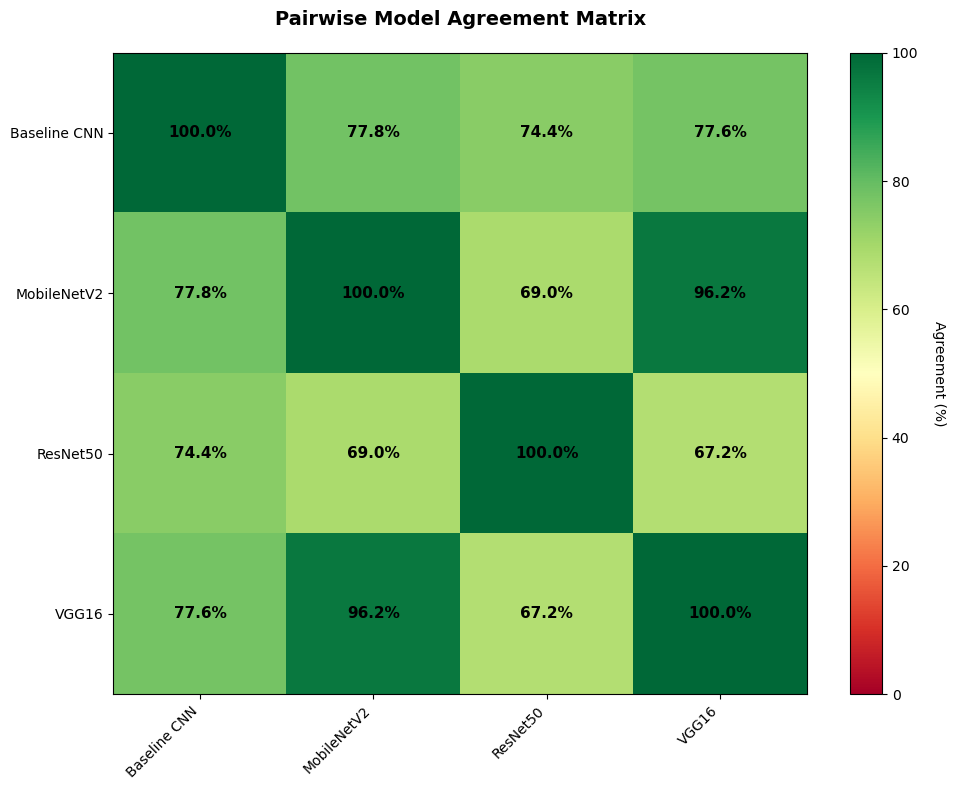

Saved: comparison_agreement_heatmap.png


In [39]:
# PREDICTION AGREEMENT HEATMAP
# Create pairwise agreement matrix
model_names = list(predictions.keys())
n_models = len(model_names)
agreement_matrix = np.zeros((n_models, n_models))

for i, name1 in enumerate(model_names):
    for j, name2 in enumerate(model_names):
        if i == j:
            agreement_matrix[i, j] = 100.0
        else:
            pred1 = predictions[name1]['pred_label']
            pred2 = predictions[name2]['pred_label']
            agreement = (pred1 == pred2).mean() * 100
            agreement_matrix[i, j] = agreement

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(agreement_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Set ticks and labels
ax.set_xticks(np.arange(n_models))
ax.set_yticks(np.arange(n_models))
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_yticklabels(model_names)

# Add text annotations
for i in range(n_models):
    for j in range(n_models):
        text = ax.text(j, i, f'{agreement_matrix[i, j]:.1f}%',
                      ha="center", va="center", color="black", fontsize=11, fontweight='bold')

ax.set_title('Pairwise Model Agreement Matrix', fontsize=14, fontweight='bold', pad=20)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Agreement (%)', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig(output_dir / 'comparison_agreement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_agreement_heatmap.png")

## 5. Confidence Distribution Comparison (Box Plots)

C:\Users\junle\AppData\Local\Temp\ipykernel_28632\1087028344.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True, showmeans=True)


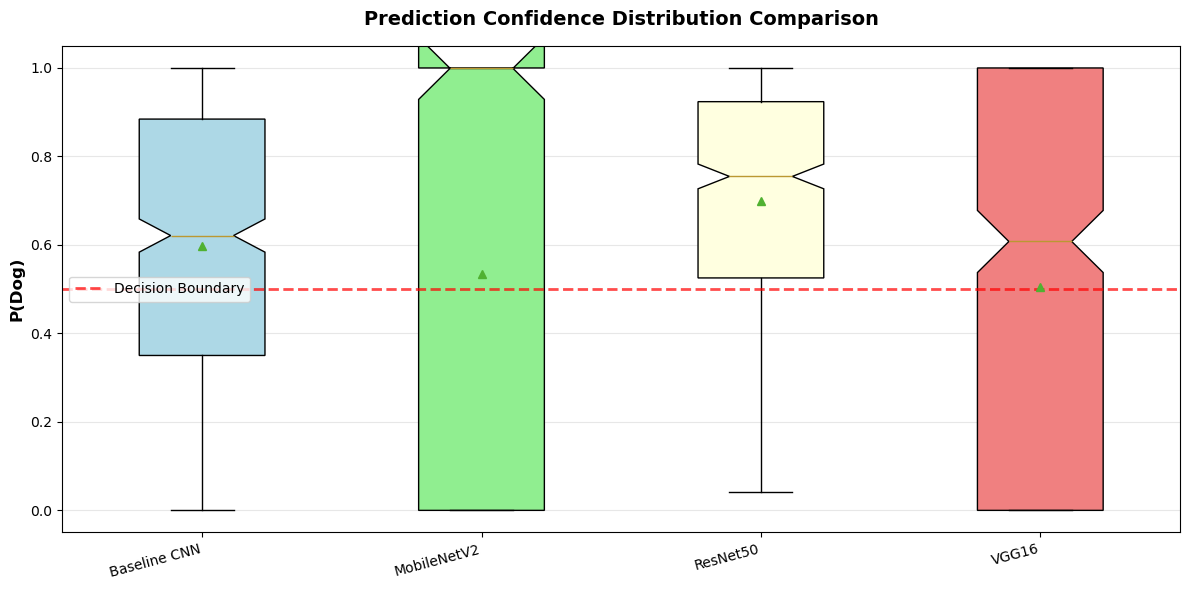

Saved: comparison_confidence_boxplot.png


In [40]:
# CONFIDENCE COMPARISON (Box plots)
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for box plot
data_to_plot = []
labels = []
for name, df in predictions.items():
    data_to_plot.append(df['prob_dog'].values)
    labels.append(name)

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True, showmeans=True)

# Customize colors
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)

ax.axhline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Decision Boundary')
ax.set_ylabel('P(Dog)', fontsize=12, fontweight='bold')
ax.set_title('Prediction Confidence Distribution Comparison', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(output_dir / 'comparison_confidence_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_confidence_boxplot.png")

## 6. Sample Predictions Gallery

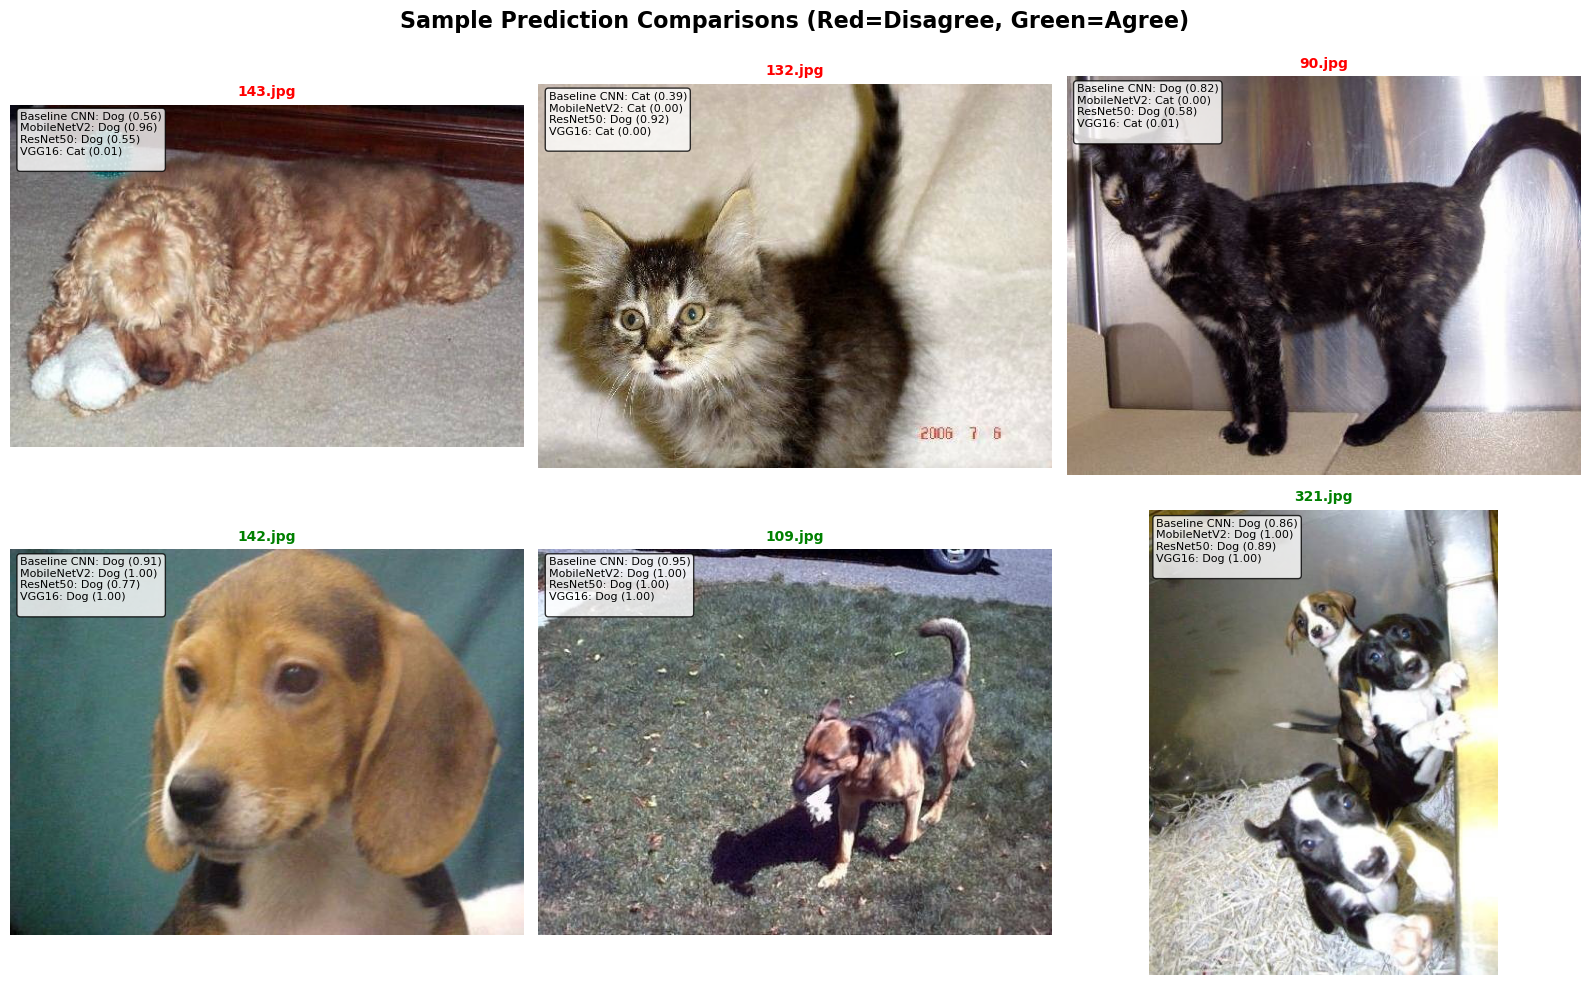

Saved: comparison_sample_predictions.png


In [41]:
# SAMPLE PREDICTIONS COMPARISON (Show specific images with all model predictions)
# Select interesting samples: high agreement, low agreement, edge cases
n_samples = 6

# Get some disagreement cases and some agreement cases
disagree_samples = merged[~merged['all_agree']].sample(min(3, len(disagreements)), random_state=42)
agree_samples = merged[merged['all_agree']].sample(min(3, len(merged[merged['all_agree']])), random_state=42)
sample_images = pd.concat([disagree_samples, agree_samples])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Sample Prediction Comparisons (Red=Disagree, Green=Agree)', fontsize=16, fontweight='bold')

for idx, (_, row) in enumerate(sample_images.iterrows()):
    if idx >= 6:
        break
    
    ax = axes[idx // 3, idx % 3]
    
    # Load and display image
    img_path = Path('datasets_subset') / 'test' / row['filename']
    if img_path.exists():
        img = mpimg.imread(img_path)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center', fontsize=16)
    
    ax.axis('off')
    
    # Add prediction info
    title_color = 'green' if row['all_agree'] else 'red'
    ax.set_title(f"{row['filename']}", fontsize=10, fontweight='bold', color=title_color)
    
    # Create text box with all predictions
    pred_text = ""
    for name in predictions.keys():
        pred_val = row[f'{name}_pred']
        # Handle both string ('dog'/'cat') and numeric (1/0) predictions
        pred_label = 'Dog' if (pred_val == 'dog' or pred_val == 1) else 'Cat'
        prob = row[f'{name}_prob']
        pred_text += f"{name}: {pred_label} ({prob:.2f})\n"
    
    ax.text(0.02, 0.98, pred_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(output_dir / 'comparison_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_sample_predictions.png")

## 7. Comprehensive Summary Table

In [42]:
# COMPREHENSIVE SUMMARY TABLE
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON SUMMARY")
print("="*80 + "\n")

summary_data = []
for name, df in predictions.items():
    # Calculate statistics
    n_dog = (df['pred_label'] == 1).sum()
    n_cat = (df['pred_label'] == 0).sum()
    mean_conf = df['prob_dog'].mean()
    std_conf = df['prob_dog'].std()
    median_conf = df['prob_dog'].median()
    
    # Confidence in predictions (how far from 0.5)
    avg_certainty = np.abs(df['prob_dog'] - 0.5).mean()
    
    summary_data.append({
        'Model': name,
        'Total': len(df),
        'Pred Dog': n_dog,
        'Pred Cat': n_cat,
        'Mean P(Dog)': f"{mean_conf:.3f}",
        'Std P(Dog)': f"{std_conf:.3f}",
        'Median P(Dog)': f"{median_conf:.3f}",
        'Avg Certainty': f"{avg_certainty:.3f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n" + "="*80)

# Export to CSV
summary_csv_path = output_dir / 'model_comparison_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSaved: model_comparison_summary.csv")
print("\nVisual comparison analysis complete! Check outputs/ folder for all visualizations.")


COMPREHENSIVE MODEL COMPARISON SUMMARY

       Model  Total  Pred Dog  Pred Cat Mean P(Dog) Std P(Dog) Median P(Dog) Avg Certainty
Baseline CNN    500         0         0       0.597      0.302         0.621         0.278
 MobileNetV2    500         0         0       0.534      0.494         0.999         0.493
    ResNet50    500         0         0       0.700      0.254         0.755         0.286
       VGG16    500         0         0       0.505      0.486         0.608         0.479


Saved: model_comparison_summary.csv

Visual comparison analysis complete! Check outputs/ folder for all visualizations.
